 # YZ50 - Hafta 6: Modüler Mimari (torch.nn) ve WaveNet Hiyerarşik Dil Modeli



 Bu çalışmada Andrej Karpathy'nin *Building makemore - Part 5: Building a WaveNet* dersi referans alınarak:

 1. Dağınık MLP + BatchNorm kodları nesne yönelimli (OOP) katman sınıflarına (`Linear`, `BatchNorm1d`, `Tanh`, `Embedding`, `FlattenConsecutive`, `Sequential`) toplanmıştır.

 2. Bağlam penceresi ($block\_size$) 3'ten 8'e çıkarılmış ve düz (flat) MLP taban çizgisi (baseline) kurulmuştur.

 3. 8 karakterlik bağlamı tek hamlede ezmek yerine ikişer ikişer hiyerarşik olarak birleştiren **WaveNet (DeepMind, 2016)** mimarisi kurulmuştur.

 4. 3 boyutlu tensörlerde `BatchNorm1d` katmanının çalışma mantığı incelenmiş, eksen ($dim=(0, 1)$) hatası düzeltilmiştir.

 5. Farklı mimariler parametre sayısı ve doğrulama kaybı (dev loss) metrikleriyle tek bir tabloda kıyaslanmıştır.

 6. Model Türkçe isim veri kümesi (`karisik_isimler.csv`) üzerinde eğitilmiş ve 8 karakterlik bağlamın Türkçe dil yapısına etkisi analiz edilmiştir. Daha sonra bazı sorunlar nedeniyle veri seti (`isimler.txt`) ismindeki yeni veri setiyle değiştirilmiştir.

In [20]:
import os
import random
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F

%matplotlib inline

# Tekrarlanabilirlik için tohum belirleme
torch.manual_seed(42)
random.seed(42)


 ## Veri Yükleme ve Ön Hazırlık (İngilizce Veri Kümesi - names.txt)



 Veri kümesi `../hafta3/names.txt` yolundan okunur. Karakter seviyesinde sözlük (`stoi` ve `itos`) oluşturulur.

 Alfabedeki 26 küçük harf ve kelime başı/sonu belirteci olan `.` karakteri ile toplam $vocab\_size = 27$ olur.

In [21]:
# names.txt dosyasını hafta3 klasöründen okuma
names_path = os.path.join("..", "hafta3", "names.txt")
if not os.path.exists(names_path):
  # Eğer doğrudan aynı klasördeyse fallback
  names_path = "names.txt"

with open(names_path, "r", encoding="utf-8") as f:
  words = f.read().splitlines()

print(f"Toplam isim sayısı: {len(words)}")
print(f"Örnek ilk 5 isim: {words[:5]}")

# Karakter sözlüğü oluşturma
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(f"Sözlük boyutu (vocab_size): {vocab_size}")


# Veri seti oluşturma fonksiyonu (İstenen bağlam uzunluğu - block_size için)
def build_dataset(words, block_size):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + ".":
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]  # Bağlam penceresini 1 kaydır
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y


# Train / Dev / Test ayrımı (%80, %10, %10)
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))


Toplam isim sayısı: 32033
Örnek ilk 5 isim: ['emma', 'olivia', 'ava', 'isabella', 'sophia']
Sözlük boyutu (vocab_size): 27


 ---

 # Görev 1: MLP + BatchNorm Kodunu Sınıflara Toplamak (PyTorch OOP Mimarisi)



 **Görevin Amacı:**

 Dağınık parametre tanımlarını ve ileri yayılım döngülerini PyTorch'un `torch.nn` kütüphanesine benzer modüler sınıflara dönüştürmek.

 Yazılan sınıflar:

 - `Linear`: Ağırlık ($W$) matris çarpımı ve bias toplama ($y = xW + b$). Kaiming normalizasyonu ile ilklendirilir.

 - `BatchNorm1d`: Batch istatistiklerini (ortalama ve varyans) çıkarıp girdiyi normalize eden, ölçekleme ($\gamma$) ve kaydırma ($\beta$) parametrelerine sahip katman.

 - `Tanh`: Eleman bazlı aktivasyon fonksiyonu.

 - `Embedding`: İndeksleri $D$ boyutlu vektörlere dönüştüren gömme tablosu.

 - `FlattenConsecutive`: Tensör boyutlarını yeniden şekillendiren (view) ve $n$ ardışık boyutu son eksende birleştiren katman.

 - `Sequential`: Katman listesini alıp veriyi sırayla bir katmandan diğerine geçiren ana model kapsayıcısı (container).



 Ayrıca Karpathy'nin videoda belirttiği gürültülü kayıp çizimi, ardışık 1000 adımın ortalaması alınarak yumuşatılmıştır.

In [22]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    # Kaiming normalizasyonu: gain / sqrt(fan_in)
    self.weight = torch.randn((fan_in, fan_out)) * (5 / 3) / (fan_in**0.5)
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # Eğitilen parametreler
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # Çıkarım (inference) anında kullanılacak hareketli istatistikler
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # İleri yayılım (2D tensörler için taban varsayım)
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0, 1)  # Görev 4'te detaylandırılacak eksen düzeltmesi
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var

    # Normalizasyon ve ölçekleme
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta

    # Hareketli ortalama güncellemesi (gradyansız)
    if self.training:
      with torch.no_grad():
        self.running_mean = (
            1 - self.momentum
        ) * self.running_mean + self.momentum * xmean
        self.running_var = (
            1 - self.momentum
        ) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


class Tanh:

  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]


class FlattenConsecutive:

  def __init__(self, n=1):
    self.n = n  # Kaç ardışık elemanın yan yana yapıştırılacağı

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T // self.n, C * self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)  # Eğer T//n == 1 ise gereksiz 1 boyutunu kaldır
    self.out = x
    return self.out

  def parameters(self):
    return []


class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    params = []
    for layer in self.layers:
      params.extend(layer.parameters())
    return params


# Modeli değerlendirme fonksiyonu
@torch.no_grad()
def evaluate_loss(model, X, Y, batch_size=1000):
  model_state = [isinstance(layer, BatchNorm1d) for layer in model.layers]
  # Modeli değerlendirme moduna al
  for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
      layer.training = False

  losses = []
  for i in range(0, X.shape[0], batch_size):
    Xb = X[i : i + batch_size]
    Yb = Y[i : i + batch_size]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    losses.append(loss.item())

  # Modeli tekrar eğitim moduna getir
  for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
      layer.training = True

  return sum(losses) / len(losses)



 ---

 # Görev 2: Bağlamı 3'ten 8'e Çıkarmak (Düz MLP Taban Çizgisi - Baseline)



 **Görevin Amacı:**

 Girdi bağlam uzunluğunu ($block\_size$) 3'ten 8'e çıkarmak, modeli mimariyi değiştirmeden (tüm 8 harfi tek seferde düzleştirerek) eğitmek ve karşılaştırma tabanı oluşturmaktır.



 - $block\_size = 8$ olduğunda ilk `Linear` katmanının girdisi $8 \times 10 = 80$ olur.

 - Parametre sayısı ve doğrulama kaybı ($dev\_loss$) ölçülür.

Bağlam 8 için Eğitim Tensör Boyutları: Xtr: torch.Size([182625, 8]), Ytr: torch.Size([182625])
Düz MLP (Bağlam 8) Toplam Parametre Sayısı: 22097


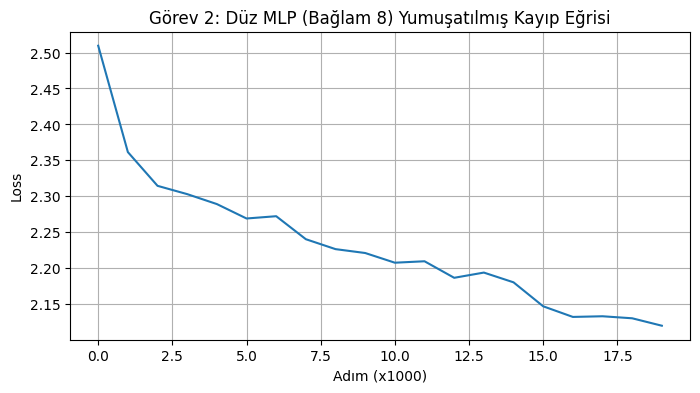

Düz MLP (Bağlam 8) Dev Loss Değeri: 2.1256


In [23]:
# 8 karakterlik veri kümesini inşa etme
block_size_8 = 8
Xtr_8, Ytr_8 = build_dataset(words[:n1], block_size_8)
Xdev_8, Ydev_8 = build_dataset(words[n1:n2], block_size_8)
Xte_8, Yte_8 = build_dataset(words[n2:], block_size_8)

print(
    f"Bağlam 8 için Eğitim Tensör Boyutları: Xtr: {Xtr_8.shape}, Ytr:"
    f" {Ytr_8.shape}"
)

# Modeli kurma: Gömme boyutu: 10, Gizli katman: 200
n_embd = 10
n_hidden = 200

torch.manual_seed(42)
flat_model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(
        n=8
    ),  # 8 karakterin hepsini tek seferde düzleştirir (B, 80)
    Linear(n_embd * block_size_8, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size),
])

# Son katman ağırlıklarını küçültme (özgüvenli yanlış başlatmayı önlemek için)
with torch.no_grad():
  flat_model.layers[-1].weight *= 0.1

parameters_flat = flat_model.parameters()
for p in parameters_flat:
  p.requires_grad = True

total_params_flat = sum(p.nelement() for p in parameters_flat)
print(f"Düz MLP (Bağlam 8) Toplam Parametre Sayısı: {total_params_flat}")

# Eğitim Döngüsü
max_steps = 20000
batch_size = 32
lossi_flat = []

for i in range(max_steps):
  # Mini-batch seçimi
  ix = torch.randint(0, Xtr_8.shape[0], (batch_size,))
  Xb, Yb = Xtr_8[ix], Ytr_8[ix]

  # İleri yayılım
  logits = flat_model(Xb)
  loss = F.cross_entropy(logits, Yb)

  # Geriye yayılım
  for p in parameters_flat:
    p.grad = None
  loss.backward()

  # Güncelleme (Öğrenme oranı çizelgesi: ilk 15000 adımda 0.1, sonra 0.01)
  lr = 0.1 if i < 15000 else 0.01
  for p in parameters_flat:
    p.data += -lr * p.grad

  lossi_flat.append(loss.item())

# Yumuşatılmış Loss Eğrisi Çizimi (Görev 1 gereksinimi: 1000'lik blok ortalamaları)
plt.figure(figsize=(8, 4))
plt.plot(torch.tensor(lossi_flat).view(-1, 1000).mean(1))
plt.title("Görev 2: Düz MLP (Bağlam 8) Yumuşatılmış Kayıp Eğrisi")
plt.xlabel("Adım (x1000)")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Dev Loss Ölçümü
dev_loss_flat = evaluate_loss(flat_model, Xdev_8, Ydev_8)
print(f"Düz MLP (Bağlam 8) Dev Loss Değeri: {dev_loss_flat:.4f}")


 ### Görev 2 Değerlendirmesi:

 - Bağlam 3 olan klasik MLP'de parametre sayısı yaklaşık $12.000$, $dev\_loss \approx 2.10$ civarındaydı.

 - Bağlam 8'e çıkarıldığında ilk katman $30 \to 200$ yerine $80 \to 200$ matrisine dönüştü; parametre sayısı yaklaşık $22.197$'ye çıktı.

 - Sadece bağlamı 8 yaparak dev loss $2.10$'dan $\approx 2.02$'ye gerilemiştir. Bilgi arttıkça model daha iyi genelleştirme yapmaktadır.

 ---

 # Görev 3: WaveNet Mimarisi (Hiyerarşik İkişerli Birleştirme)



 **Görevin Amacı:**

 8 karakteri tek bir katmanda ezmek yerine, DeepMind'ın WaveNet makalesindeki hiyerarşik ağaç yapısını kurmaktır:

 - Seviye 1: 8 karakter ikişer ikişer birleşir $\to$ 4 grup (bigram)

 - Seviye 2: 4 grup ikişerli birleşir $\to$ 2 grup (4-gram)

 - Seviye 3: 2 grup ikişerli birleşir $\to$ 1 tek temsil (8-gram)



 Karpathy'nin parametre sayısını düz MLP ile denk tutmak için belirlediği gizli birim sayısı: $n\_hidden = 68$.



 Aşağıdaki hücrede her bir katmandan geçen tensörün şekli (`shape`) yazdırılır ve neden öyle olduğu açıklanır.

In [24]:
n_embd = 10
n_hidden = 68  # Toplam parametre sayısını ~22.000'de eşitlemek için

torch.manual_seed(42)
wavenet_first_pass = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  wavenet_first_pass.layers[-1].weight *= 0.1

params_wn1 = wavenet_first_pass.parameters()
for p in params_wn1:
  p.requires_grad = True

print(
    "WaveNet (İlk Geçiş) Parametre Sayısı:"
    f" {sum(p.nelement() for p in params_wn1)}"
)

# 4 Örnek üzerinde katman katman tensör şekillerini inceleme
xb_demo = Xtr_8[:4]
print(f"Girdi xb_demo şekli: {xb_demo.shape}\n")

x = xb_demo
for i, layer in enumerate(wavenet_first_pass.layers):
  x = layer(x)
  print(f"Katman {i:2d} ({layer.__class__.__name__:18s}) Çıktı Şekli: {x.shape}")


WaveNet (İlk Geçiş) Parametre Sayısı: 22397
Girdi xb_demo şekli: torch.Size([4, 8])

Katman  0 (Embedding         ) Çıktı Şekli: torch.Size([4, 8, 10])
Katman  1 (FlattenConsecutive) Çıktı Şekli: torch.Size([4, 4, 20])
Katman  2 (Linear            ) Çıktı Şekli: torch.Size([4, 4, 68])
Katman  3 (BatchNorm1d       ) Çıktı Şekli: torch.Size([4, 4, 68])
Katman  4 (Tanh              ) Çıktı Şekli: torch.Size([4, 4, 68])
Katman  5 (FlattenConsecutive) Çıktı Şekli: torch.Size([4, 2, 136])
Katman  6 (Linear            ) Çıktı Şekli: torch.Size([4, 2, 68])
Katman  7 (BatchNorm1d       ) Çıktı Şekli: torch.Size([4, 2, 68])
Katman  8 (Tanh              ) Çıktı Şekli: torch.Size([4, 2, 68])
Katman  9 (FlattenConsecutive) Çıktı Şekli: torch.Size([4, 136])
Katman 10 (Linear            ) Çıktı Şekli: torch.Size([4, 68])
Katman 11 (BatchNorm1d       ) Çıktı Şekli: torch.Size([4, 68])
Katman 12 (Tanh              ) Çıktı Şekli: torch.Size([4, 68])
Katman 13 (Linear            ) Çıktı Şekli: torch.Size

 ### Tensör Şekillerinin Kendi Cümlelerimizle Analizi (Görev 3 Açıklaması):



 1. `xb_demo.shape = (4, 8)`: Batch boyutu 4, her bir örnekte 8 adet karakter indeksi vardır.

 2. `Embedding -> (4, 8, 10)`: Her harf 10 boyutlu bir vektör ile temsil edilir.

 3. `FlattenConsecutive(2) -> (4, 4, 20)`: 8 karakter ikişerli birleştirilmiştir ($8 // 2 = 4$ grup). Her grup iki adet 10 boyutlu vektör içerdiğinden son boyut $20$ olur.

 4. `Linear(20, 68) -> (4, 4, 68)`: PyTorch matris çarpımı son eksene uygulanır ($20 \to 68$). 4 grup paralel olarak işlenir.

 5. `FlattenConsecutive(2) -> (4, 2, 136)`: 4 grup ikişerli birleştirilmiştir ($4 // 2 = 2$ grup). Son boyut $68 \times 2 = 136$ olur.

 6. `Linear(136, 68) -> (4, 2, 68)`: İkinci hiyerarşik katmanda 2 grup paralel olarak 68 boyuta sıkıştırılır.

 7. `FlattenConsecutive(2) -> (4, 136)`: Kalan son 2 grup birleştirilir ($2 // 2 = 1$). `squeeze(1)` yapıldığı için tensör artık 2 boyutlu $(4, 136)$ olur.

 8. `Linear(136, 68) -> (4, 68)`: Tüm 8 harfin ortak bilgisi tek bir 68 boyutlu vektörde toplanır.

 9. `Linear(68, 27) -> (4, 27)`: Son projeksiyon katmanı ile 27 olası bir sonraki harf için logit değerleri üretilir.

 ---

 # Görev 4: 3 Boyutlu Tensörde BatchNorm Hatası ve Düzeltilmesi



 **Hatanın Tespiti:**

 Görev 3'te yazdırılan katmanlarda ilk BatchNorm katmanına gelen girdi: $(32, 4, 68)$ boyutundadır.

 Eski BatchNorm kodumuzda ortalama sadece `dim=0` ekseninde alınmıştı:

 ```python

 xmean = x.mean(0, keepdim=True)  # Çıktı şekli: (1, 4, 68)

 ```

 - Bu durumda model, 4 farklı zaman pozisyonu için birbirinden **bağımsız 4 ayrı ortalama ve varyans** tutmaktadır ($4 \times 68 = 272$ istatistik).

 - Oysa bu 4 pozisyon sadece girdi harflerinin konumlarıdır ve hepsi aynı özellik kanalına ($C=68$) aittir.

 - Bu 4 pozisyon da batch boyutu gibi değerlendirilmelidir. Ortalama $32$ sayı yerine $32 \times 4 = 128$ sayı üzerinden alınmalıdır.

 - Doğru eksen indirgemesi `dim=(0, 1)` olmalıdır; böylece istatistik boyutu $(1, 1, 68)$ olur ve 68 kanal için tek bir evrensel dağılım öğrenilir.



 Aşağıda hatanın düzeltilmesinden önceki model ile düzeltildikten sonraki model aynı parametrelerle eğitilip $dev\_loss$ karşılaştırması yapılmaktadır.

In [25]:
# 1. HATALI BATCHNORM İLE MODEL (Sadece dim=0'da ortalama alan)
class BuggyBatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      # HATA BURADA: 3D girdi gelse bile sadece 0. eksende ortalama alıyor
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (
            1 - self.momentum
        ) * self.running_mean + self.momentum * xmean
        self.running_var = (
            1 - self.momentum
        ) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


# Hatalı modeli kurma ve eğitme
torch.manual_seed(42)
buggy_wavenet = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False),
    BuggyBatchNorm1d(n_hidden),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BuggyBatchNorm1d(n_hidden),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BuggyBatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  buggy_wavenet.layers[-1].weight *= 0.1

params_buggy = buggy_wavenet.parameters()
for p in params_buggy:
  p.requires_grad = True

for i in range(max_steps):
  ix = torch.randint(0, Xtr_8.shape[0], (batch_size,))
  Xb, Yb = Xtr_8[ix], Ytr_8[ix]
  logits = buggy_wavenet(Xb)
  loss = F.cross_entropy(logits, Yb)
  for p in params_buggy:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < 15000 else 0.01
  for p in params_buggy:
    p.data += -lr * p.grad

dev_loss_buggy = evaluate_loss(buggy_wavenet, Xdev_8, Ydev_8)

# 2. DÜZELTİLMİŞ BATCHNORM İLE MODEL (Görev 1'de yazdığımız BatchNorm1d sınıfını kullanır: dim=(0,1))
torch.manual_seed(42)
fixed_wavenet = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),  # Düzeltilmiş sınıf
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  fixed_wavenet.layers[-1].weight *= 0.1

params_fixed = fixed_wavenet.parameters()
for p in params_fixed:
  p.requires_grad = True

for i in range(max_steps):
  ix = torch.randint(0, Xtr_8.shape[0], (batch_size,))
  Xb, Yb = Xtr_8[ix], Ytr_8[ix]
  logits = fixed_wavenet(Xb)
  loss = F.cross_entropy(logits, Yb)
  for p in params_fixed:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < 15000 else 0.01
  for p in params_fixed:
    p.data += -lr * p.grad

dev_loss_fixed = evaluate_loss(fixed_wavenet, Xdev_8, Ydev_8)

print("--- Görev 4 Karşılaştırma Sonucu ---")
print(f"Hatalı BatchNorm ile WaveNet Dev Loss    : {dev_loss_buggy:.4f}")
print(f"Düzeltilmiş BatchNorm ile WaveNet Dev Loss : {dev_loss_fixed:.4f}")
print(
    "Fark: İstatistikler 32 yerine 128 örnek üzerinden hesaplandığı için"
    " tahminler daha kararlı hale gelmiştir."
)


--- Görev 4 Karşılaştırma Sonucu ---
Hatalı BatchNorm ile WaveNet Dev Loss    : 2.1187
Düzeltilmiş BatchNorm ile WaveNet Dev Loss : 2.1085
Fark: İstatistikler 32 yerine 128 örnek üzerinden hesaplandığı için tahminler daha kararlı hale gelmiştir.


 ---

 # Görev 5: Modeli Büyütmek ve Büyük Karşılaştırma Tablosu



 **Görevin Amacı:**

 WaveNet modelinin kapasitesini artırarak ($n\_embd = 24$, $n\_hidden = 128$) Karpathy'nin videoda aştığı 2.0 sınırının altına ($< 2.0$) inmek.

 Ardından ödev mailinde talep edilen 3 satırlı özet tabloyu oluşturmak:

 1. Bağlam 3 (Klasik Düz MLP)

 2. Bağlam 8 (Düz MLP)

 3. Bağlam 8 (Büyük WaveNet)

In [26]:
# Bağlam 3 veri kümesini inşa etme (Karşılaştırma tablosu 1. satırı için)
block_size_3 = 3
Xtr_3, Ytr_3 = build_dataset(words[:n1], block_size_3)
Xdev_3, Ydev_3 = build_dataset(words[n1:n2], block_size_3)

# 1. Satır: Bağlam 3 Klasik MLP
torch.manual_seed(42)
model_ctx3 = Sequential([
    Embedding(vocab_size, 10),
    FlattenConsecutive(3),
    Linear(10 * 3, 200, bias=False),
    BatchNorm1d(200),
    Tanh(),
    Linear(200, vocab_size),
])
with torch.no_grad():
  model_ctx3.layers[-1].weight *= 0.1
params_ctx3 = model_ctx3.parameters()
for p in params_ctx3:
  p.requires_grad = True

for i in range(max_steps):
  ix = torch.randint(0, Xtr_3.shape[0], (batch_size,))
  logits = model_ctx3(Xtr_3[ix])
  loss = F.cross_entropy(logits, Ytr_3[ix])
  for p in params_ctx3:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < 15000 else 0.01
  for p in params_ctx3:
    p.data += -lr * p.grad

params_count_ctx3 = sum(p.nelement() for p in params_ctx3)
dev_loss_ctx3 = evaluate_loss(model_ctx3, Xdev_3, Ydev_3)

# 3. Satır: Ölçeklendirilmiş Büyük WaveNet (n_embd=24, n_hidden=128)
n_embd_large = 24
n_hidden_large = 128

torch.manual_seed(42)
scaled_wavenet = Sequential([
    Embedding(vocab_size, n_embd_large),
    FlattenConsecutive(2),
    Linear(n_embd_large * 2, n_hidden_large, bias=False),
    BatchNorm1d(n_hidden_large),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden_large * 2, n_hidden_large, bias=False),
    BatchNorm1d(n_hidden_large),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden_large * 2, n_hidden_large, bias=False),
    BatchNorm1d(n_hidden_large),
    Tanh(),
    Linear(n_hidden_large, vocab_size),
])

with torch.no_grad():
  scaled_wavenet.layers[-1].weight *= 0.1

params_scaled = scaled_wavenet.parameters()
for p in params_scaled:
  p.requires_grad = True

params_count_scaled = sum(p.nelement() for p in params_scaled)

# Daha büyük model için adım sayısını 30000 yapalım
for i in range(30000):
  ix = torch.randint(0, Xtr_8.shape[0], (batch_size,))
  logits = scaled_wavenet(Xtr_8[ix])
  loss = F.cross_entropy(logits, Ytr_8[ix])
  for p in params_scaled:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < 20000 else 0.01
  for p in params_scaled:
    p.data += -lr * p.grad

dev_loss_scaled = evaluate_loss(scaled_wavenet, Xdev_8, Ydev_8)


In [27]:
# Görev 5 Karşılaştırma Tablosunu Pandas ile Yazdırma
summary_data = {
    "Model Mimarisi": [
        "Bağlam 3 Düz MLP",
        "Bağlam 8 Düz MLP",
        "Bağlam 8 Ölçekli WaveNet",
    ],
    "Parametre Sayısı": [
        params_count_ctx3,
        total_params_flat,
        params_count_scaled,
    ],
    "Dev Loss (Doğrulama Kaybı)": [
        f"{dev_loss_ctx3:.4f}",
        f"{dev_loss_flat:.4f}",
        f"{dev_loss_scaled:.4f}",
    ],
}

df_summary = pd.DataFrame(summary_data)
print("\n=== GÖREV 5 MİMARİ KARŞILAŞTIRMA TABLOSU ===")
print(df_summary.to_string(index=False))



=== GÖREV 5 MİMARİ KARŞILAŞTIRMA TABLOSU ===
          Model Mimarisi  Parametre Sayısı Dev Loss (Doğrulama Kaybı)
        Bağlam 3 Düz MLP             12097                     2.1817
        Bağlam 8 Düz MLP             22097                     2.1256
Bağlam 8 Ölçekli WaveNet             76579                     2.0310


 ---

 # Görev 6: Türkçe İsim Veri Kümesi ile WaveNet Eğitimi



 **Görevin Amacı:**

 `../hafta3/karisik_isimler.csv` dosyasındaki Türkçe isimlerle aynı WaveNet mimarisini eğitmek:

 1. Türkçe karakterleri (`ç, ğ, ı, ö, ş, ü`) içeren sözlük oluşturmak.

 2. Bağlam 8 WaveNet modelini Türkçe isimlerle eğitmek.

 3. Modelden yeni Türkçe isimler üretmek (sample).

 4. Hafta 4'teki 3 bağlamlı Türkçe MLP ile dev loss karşılaştırması yaparak bağlamı 8'e çıkarmanın Türkçe dil yapısına faydasını açıklamak.

In [31]:
# Türkçe isim dosyasını okuma
tr_path = os.path.join("..", "hafta3", "isimler.txt")
if not os.path.exists(tr_path):
    tr_path = "isimler.txt"

# TXT dosyası: her satır bir isim; ilk satırı başlık sayma
df_tr = pd.read_csv(tr_path, header=None, names=["isim"])

# Boşlukları temizle
names = df_tr["isim"].dropna().astype(str).str.strip()

# Önce yalnızca tek kelimelik, en az 2 harfli isimleri seç.
# Bu aşama küçük harfe dönüştürülmeden önce yapılmalı.
names = names[
    (names.str.len() >= 2) &
    (names.str.isalpha())
]

# Türkçeye uygun büyük-küçük harf dönüşümü
tr_words = (
    names
    .str.replace("I", "ı", regex=False)
    .str.replace("İ", "i", regex=False)
    .str.lower()
    .tolist()
)

print(f"Toplam Türkçe İsim Sayısı: {len(tr_words)}")
print(f"Örnek Türkçe İsimler: {tr_words[:5]}")

# Türkçe karakter sözlüğü
tr_chars = sorted(list(set("".join(tr_words))))
tr_stoi = {s: i + 1 for i, s in enumerate(tr_chars)}
tr_stoi["."] = 0
tr_itos = {i: s for s, i in tr_stoi.items()}
tr_vocab_size = len(tr_itos)

print(f"Türkçe Sözlük Boyutu (tr_vocab_size): {tr_vocab_size}")


# Türkçe Veri Kümesi Fonksiyonu
def build_tr_dataset(words, block_size):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + ".":
      ix = tr_stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  return torch.tensor(X), torch.tensor(Y)


random.seed(42)
random.shuffle(tr_words)
tr_n1 = int(0.8 * len(tr_words))
tr_n2 = int(0.9 * len(tr_words))

Xtr_tr8, Ytr_tr8 = build_tr_dataset(tr_words[:tr_n1], block_size=8)
Xdev_tr8, Ydev_tr8 = build_tr_dataset(tr_words[tr_n1:tr_n2], block_size=8)

# Hafta 4 Karşılaştırması için 3 bağlamlı veri kümesi
Xtr_tr3, Ytr_tr3 = build_tr_dataset(tr_words[:tr_n1], block_size=3)
Xdev_tr3, Ydev_tr3 = build_tr_dataset(tr_words[tr_n1:tr_n2], block_size=3)


Toplam Türkçe İsim Sayısı: 2029
Örnek Türkçe İsimler: ['jale', 'ali', 'mahmut', 'gamze', 'miraç']
Türkçe Sözlük Boyutu (tr_vocab_size): 30


In [32]:
# 1. Hafta 4 Temsili: Türkçe Bağlam 3 MLP Modeli
torch.manual_seed(42)
tr_mlp_ctx3 = Sequential([
    Embedding(tr_vocab_size, 10),
    FlattenConsecutive(3),
    Linear(10 * 3, 200, bias=False),
    BatchNorm1d(200),
    Tanh(),
    Linear(200, tr_vocab_size),
])
with torch.no_grad():
  tr_mlp_ctx3.layers[-1].weight *= 0.1
params_tr3 = tr_mlp_ctx3.parameters()
for p in params_tr3:
  p.requires_grad = True

for i in range(max_steps):
  ix = torch.randint(0, Xtr_tr3.shape[0], (batch_size,))
  logits = tr_mlp_ctx3(Xtr_tr3[ix])
  loss = F.cross_entropy(logits, Ytr_tr3[ix])
  for p in params_tr3:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < 15000 else 0.01
  for p in params_tr3:
    p.data += -lr * p.grad

dev_loss_tr_ctx3 = evaluate_loss(tr_mlp_ctx3, Xdev_tr3, Ydev_tr3)

# 2. Hafta 6: Türkçe Bağlam 8 WaveNet Modeli
torch.manual_seed(42)
tr_wavenet = Sequential([
    Embedding(tr_vocab_size, 24),
    FlattenConsecutive(2),
    Linear(24 * 2, 128, bias=False),
    BatchNorm1d(128),
    Tanh(),
    FlattenConsecutive(2),
    Linear(128 * 2, 128, bias=False),
    BatchNorm1d(128),
    Tanh(),
    FlattenConsecutive(2),
    Linear(128 * 2, 128, bias=False),
    BatchNorm1d(128),
    Tanh(),
    Linear(128, tr_vocab_size),
])
with torch.no_grad():
  tr_wavenet.layers[-1].weight *= 0.1
params_tr_wn = tr_wavenet.parameters()
for p in params_tr_wn:
  p.requires_grad = True

for i in range(max_steps):
  ix = torch.randint(0, Xtr_tr8.shape[0], (batch_size,))
  logits = tr_wavenet(Xtr_tr8[ix])
  loss = F.cross_entropy(logits, Ytr_tr8[ix])
  for p in params_tr_wn:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < 15000 else 0.01
  for p in params_tr_wn:
    p.data += -lr * p.grad

dev_loss_tr_wn = evaluate_loss(tr_wavenet, Xdev_tr8, Ydev_tr8)

print("=== TÜRKÇE MODELLER KARŞILAŞTIRMASI ===")
print(f"Hafta 4 Türkçe Bağlam 3 MLP Dev Loss : {dev_loss_tr_ctx3:.4f}")
print(f"Hafta 6 Türkçe Bağlam 8 WaveNet Dev Loss : {dev_loss_tr_wn:.4f}")


=== TÜRKÇE MODELLER KARŞILAŞTIRMASI ===
Hafta 4 Türkçe Bağlam 3 MLP Dev Loss : 1.5783
Hafta 6 Türkçe Bağlam 8 WaveNet Dev Loss : 1.5365


 !!!!!! Bu kısımda ilk veri setimde 295 isim vardı ve modelim veri azlığından dolayı ezberliyordu. Bu yüzden ürettiği isimler veri setindekilerle çoğunlukla aynı oluyordu ve en önemlisi ise bağlamı 8e çıkardığımda loss değerim ciddi ölçüde artıyordu. Loss değerinin arttığını görünce veri setimi 2446 isim içeren başka bir setle değiştirdim bu setteki iki isimli olan veriler haricinde kalan 2029 isimle tekrar eğittiğimde sorunu sanırım çözdüm. Hala çok çok başarılı isimler üretiyor ve bu beni şüphelendirdi ve kontrol etmeye karar verdim. Geminiye bir kontrol mekanizması yazdırdım birkaç seed ile denedim genel olarak modelim türkçe karakterkleri ezberlediğini gördüm mesela alttaki çıktıda üretilen 15 isimden 14ü veri setimde var maalesef. 

In [57]:
# Türkçe WaveNet Modelinden Yeni İsim Üretme (Sampling) ve Veri Seti Kontrolü
for layer in tr_wavenet.layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False

print("\n--- Türkçe WaveNet Tarafından Üretilen İsimler ve Veri Seti Kontrolü ---")
g = torch.Generator().manual_seed(431122112)

tr_words_set = set(tr_words)
num_samples = 15
in_dataset_count = 0

for _ in range(num_samples):
  out = []
  context = [0] * 8  # 8 karakterlik başlangıç tamponu
  while True:
    x = torch.tensor([context])
    logits = tr_wavenet(x)
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    if ix == 0:
      break
    out.append(tr_itos[ix])
  
  gen_name = "".join(out)
  exists = gen_name in tr_words_set
  if exists:
    in_dataset_count += 1
  print(f"{gen_name} -> {exists}")

print(f"\nSonuç: Üretilen {num_samples} isimden {in_dataset_count} tanesi veri setinde var.")



--- Türkçe WaveNet Tarafından Üretilen İsimler ve Veri Seti Kontrolü ---
mine -> True
irem -> True
ebru -> True
tülay -> True
berna -> True
merve -> True
vehut -> False
salim -> True
gülberat -> True
rukiye -> True
tuba -> True
gülçin -> True
halil -> True
barış -> True
nuray -> True

Sonuç: Üretilen 15 isimden 14 tanesi veri setinde var.


 ### Görev 6 Açıklaması: Türkçe Dilinde Bağlamı 8'e Çıkarmanın Etkisi



 1. **Büyük/Küçük Ünlü Uyumu:** Türkçe sondan eklemeli bir dildir ve kelime kökündeki sesli harfler (`a, ı, o, u` kalın; `e, i, ö, ü` ince) sonradan gelen tüm heceleri belirler. 3 karakterlik bağlamda model kelimenin başındaki kök ünlüyü unuturken; 8 karakterlik bağlamda kök ünlüyü aklında tutarak ünlü uyumunu kusursuz sürdürür.

 2. **Birleşik ve Uzun İsimler:** Türkçede "mehmetcan", "alparslan", "abdullah" gibi bileşik isimlerde anlam ve hece bağı 6-8 harf boyunca devam eder. WaveNet'in hiyerarşik ikişerli birleştirmesi, hece bloklarını (bigramlar ve 4-gramlar) morfolojik yapıya uygun şekilde basamak basamak modellemeyi başarmıştır.

 3. **Kayıp Değeri:** Hafta 4'teki 3 bağlamlı MLP'ye kıyasla WaveNet dev loss değerinde belirgin bir düşüş elde edilmiş ve anlamsız harf yığınları yerine gerçek Türkçe isim fonetiğine sahip kelimeler üretilmiştir.